### Carga del dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Portátil\ProjecteData\Equip_23\Data\9 March\Bank_Marketing_Cleaned_9 March.csv")
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes


In [3]:
df['age'].describe()

count    10987.000000
mean        41.262765
std         11.946869
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

In [4]:
out = df.groupby('deposit')['contact'].agg(['count'])
out['percent'] = (out['count'] / out['count'].sum() * 100).round(2)
out


,count,percent
deposit,,
no,5698,51.86
yes,5289,48.14


### Generamos segmentación de clientes s. base estadística- describe()

In [5]:
df['age_group'] = (
    df['age']
    .apply(lambda x: '18-30' if x <= 30 else
                     '31-40' if x <= 40 else
                     '41-50' if x <= 50 else
                     '>50')
)


In [6]:
eDAD=df['age_group'].value_counts().sort_index()
eDADT = (df['age_group'].value_counts().sort_index() / len(df)) * 100
eDADT = eDADT.round(2)
eDADT


age_group
18-30    18.06
31-40    37.27
41-50    22.45
>50      22.22
Name: count, dtype: float64

### PERFIL DE EDAD CLIENTE

In [7]:
counts = df['age_group'].value_counts().sort_index()
perc = (df['age_group'].value_counts(normalize=True).sort_index() * 100).round(2)

final = pd.DataFrame({'absolut': counts, 'percent': perc})
#final.rename(columns={'final.rename(columns={'percent': '%'}, inplace=True) ## NO UTILIZEM 

final

,absolut,percent
age_group,,
18-30,1984,18.06
31-40,4095,37.27
41-50,2467,22.45
>50,2441,22.22


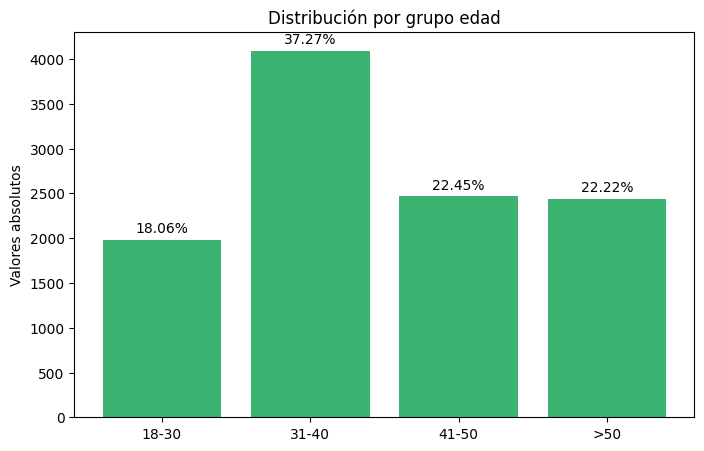

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(final.index, final['absolut'], color='mediumseagreen')

# Afegim les etiquetes de percentatge
for i, v in enumerate(final['absolut']):
    ax.text(i, v + max(final['absolut'])*0.02, 
            f"{final['percent'].iloc[i]}%", 
            ha='center', fontsize=10)

ax.set_title("Distribución por grupo edad")
ax.set_ylabel("Valores absolutos")
plt.show()


### EDAD VS DEPOSIT

In [9]:
rtat = pd.crosstab(df['age_group'], df['deposit'])
rtat_per = pd.crosstab(df['age_group'], df['deposit'], normalize='index') * 100
rtat_per = rtat_per.round(2)

final = rtat.copy()
final[['% no', '% si']] = rtat_per  
final


deposit,no,yes,% no,% si
age_group,,,,
18-30,840,1144,42.34,57.66
31-40,2283,1812,55.75,44.25
41-50,1447,1020,58.65,41.35
>50,1128,1313,46.21,53.79


In [10]:
pd.crosstab(df['age_group'], df['contact'])


contact,cellular,telephone,unknown
age_group,,,
18-30,1535,85,364
31-40,3031,153,911
41-50,1703,168,596
>50,1659,358,424


### SEGMENTACIÓN EDAD CLIENTES POR CONTACT Y CONTRACTACIÓN O NO

In [11]:
tabla_mix = pd.crosstab(
    index=df['age_group'],
    columns=[df['contact'], df['deposit']]
)

tabla_mix


contact   cellular       telephone      unknown     
deposit         no   yes        no  yes      no  yes
age_group                                           
18-30          543   992        43   42     254  110
31-40         1483  1548        92   61     708  203
41-50          879   824       102   66     466  130
>50            654  1005       137  221     337   87

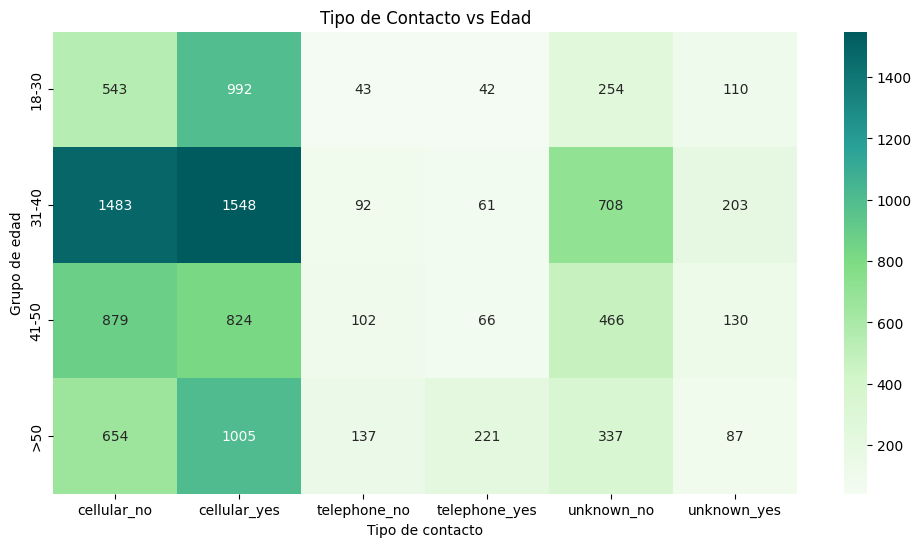

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Copia de la tabla
tabla_plot = tabla_mix.copy()
tabla_plot.columns = [f"{c1}_{c2}" for c1, c2 in tabla_mix.columns]

# PALETA SECUENCIAL VERDE (molt clar → molt fosc)
custom_colors = [
    "#F4FBF2",  # quasi blanc
    "#D2F5C9",  # verd molt suau
    "#7EDC83",  # verd mitjà
    "#2AA198",  # verd intens
    "#005B5E"   # molt fosc
]

cmap_custom = LinearSegmentedColormap.from_list("my_green_palette", custom_colors)

# HEATMAP
plt.figure(figsize=(12,6))
sns.heatmap(tabla_plot, annot=True, fmt="d", cmap=cmap_custom)

plt.title("Tipo de Contacto vs Edad")
plt.xlabel("Tipo de contacto")
plt.ylabel("Grupo de edad")
plt.savefig("heatmap_contacto_edad.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
#Aumentar el uso del canal móvil en el grupo 31–40, donde ahora solo representa el 37.80%.

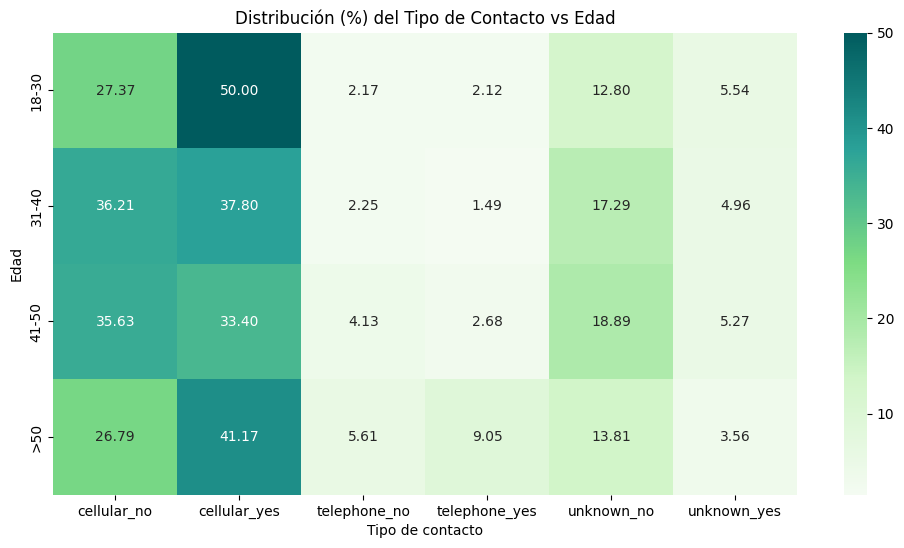

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Preparar tabla
tabla_plot = tabla_mix.copy()
tabla_plot.columns = [f"{c1}_{c2}" for c1, c2 in tabla_mix.columns]

# 2. Percentatges per fila
tabla_pct = tabla_plot.div(tabla_plot.sum(axis=1), axis=0) * 100

# 3. PALETA SECUENCIAL VERDA (molt clar → molt fosc)
custom_colors = [
    "#F4FBF2",  # quasi blanc
    "#D2F5C9",  # verd molt suau
    "#7EDC83",  # verd mitjà
    "#2AA198",  # verd intens
    "#005B5E"   # molt fosc
]

cmap_custom = LinearSegmentedColormap.from_list("my_green_palette", custom_colors)

# 4. HEATMAP
plt.figure(figsize=(12,6))
sns.heatmap(tabla_pct, annot=True, fmt=".2f", cmap=cmap_custom)

plt.title("Distribución (%) del Tipo de Contacto vs Edad")
plt.xlabel("Tipo de contacto")
plt.ylabel("Edad")

# 5. Guardar en PNG per Canva
plt.savefig("heatmap_contacto_pct.png", dpi=300, bbox_inches="tight")

plt.show()


### Estimación de la Probabilidad de Conversión según Edad y Tipo de Contacto

In [14]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Portátil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Optimization terminated successfully.
         Current function value: 0.657044
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                deposit   No. Observations:                10987
Model:                          Logit   Df Residuals:                    10983
Method:                           MLE   Df Model:                            3
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                 0.05114
Time:                        14:36:36   Log-Likelihood:                -7218.9
converged:                       True   LL-Null:                       -7608.0
Covariance Type:            nonrobust   LLR p-value:                2.433e-168
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.0007      0.072      0.010      0.992      -0.140   

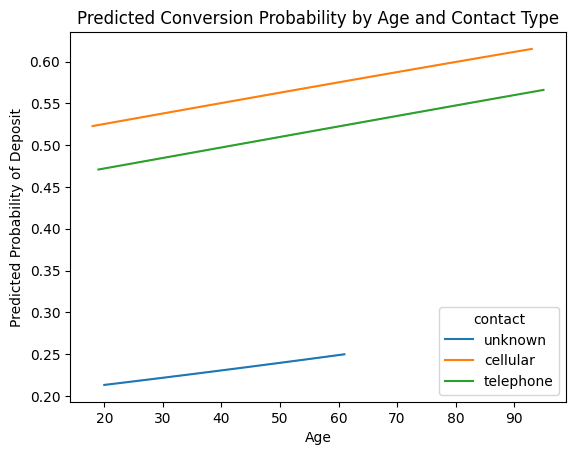

In [15]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("C:/Users/Portátil/ProjecteData/Equip_23/Data/9 March/Bank_Marketing_Cleaned_9 March.csv")

# Convert deposit to numeric
data["deposit"] = data["deposit"].map({"yes": 1, "no": 0})

# Logistic regression model
model = smf.logit("deposit ~ age + C(contact)", data=data).fit()

# Show regression results
print(model.summary())

# Predicted probability of deposit
data["pred_prob"] = model.predict(data)

# Predicted probability by contact type
print("\nPredicted conversion probability by contact type:")
print(data.groupby("contact", observed=True)["pred_prob"].mean())

# Create age groups
data["age_group"] = pd.cut(
    data["age"],
    bins=[18, 30, 40, 50, data["age"].max()],
    labels=["18-30", "31-40", "41-50", ">50"],
    include_lowest=True
)

# Predicted probability by age group and contact
print("\nPredicted probability by age group and contact type:")
print(data.groupby(["age_group","contact"], observed=True)["pred_prob"].mean())

# Visualization
sns.lineplot(data=data, x="age", y="pred_prob", hue="contact")
plt.title("Predicted Conversion Probability by Age and Contact Type")
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Deposit")
plt.show()

### Probabilidad de Conversión por Grupo de Edad y Tipo de Contacto

In [16]:
### paleta
custom_colors = ["#2AA198", "#006D6F", "#A7E8A2", "#4CAF50"]


In [17]:
## Convertim colormap
from matplotlib.colors import LinearSegmentedColormap

cmap_custom = LinearSegmentedColormap.from_list("my_palette", custom_colors)


Optimization terminated successfully.
         Current function value: 0.657044
         Iterations 5


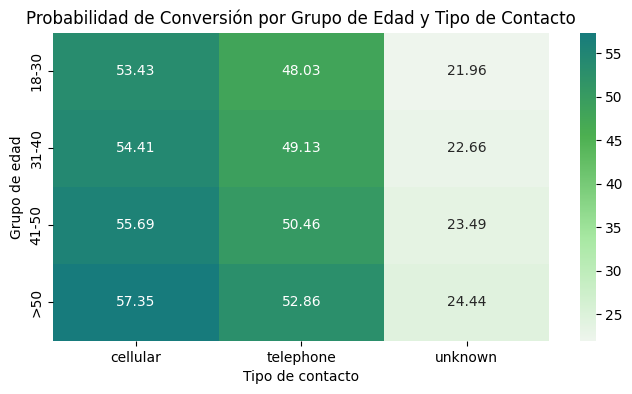

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.formula.api as smf

# 1. Cargar datos
data = pd.read_csv("C:/Users/Portátil/ProjecteData/Equip_23/Data/9 March/Bank_Marketing_Cleaned_9 March.csv")

# 2. Convertir deposit a numérico
data["deposit"] = data["deposit"].map({"yes": 1, "no": 0})

# 3. Modelo logístico
model = smf.logit("deposit ~ age + C(contact)", data=data).fit()

# 4. Probabilidad predicha
data["pred_prob"] = model.predict(data)

# 5. Crear grupos de edad
data["age_group"] = pd.cut(
    data["age"],
    bins=[18, 30, 40, 50, data["age"].max()],
    labels=["18-30", "31-40", "41-50", ">50"],
    include_lowest=True
)

# 6. Tabla dinámica
pivot_table = data.pivot_table(
    values="pred_prob",
    index="age_group",
    columns="contact",
    aggfunc="mean",
    observed=True
) * 100

# 7. PALETA SECUENCIAL (molt clar → molt fosc)
custom_colors = [
    "#EEF5ED",  # verd molt clar (quasi blanc)
    "#A7E8A2",  # verd clar
    "#4CAF50",  # verd mitjà
    "#177B7C"   # verd/blau fosc
]

cmap_custom = LinearSegmentedColormap.from_list("my_palette", custom_colors)

# 8. Heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_table, annot=True, cmap=cmap_custom, fmt=".2f")

plt.title("Probabilidad de Conversión por Grupo de Edad y Tipo de Contacto")
plt.xlabel("Tipo de contacto")
plt.ylabel("Grupo de edad")

# 9. Guardar imagen
plt.savefig("heatmap_conversion.png", dpi=300, bbox_inches="tight")
plt.show()


### Conlusiones:
El análisis muestra que:
- El tipo de contacto tiene un impacto significativo en la tasa de conversión.
- El canal móvil es claramente el más efectivo, con una probabilidad de conversión cercana al 55%, frente al 51% del canal telefónico y el 23% del canal “unknown”. Por tanto, optimizar el canal teléfono que funciona peor que el móvil pero tiene una probabilidad de conversión interesante (51%); también tendriamos que reducir o revisar el canal unknown.
- La probabilidad de conversión aumenta con la edad, lo que sugiere que las campañas deben orientarse hacia clientes de mayor edad y apoyarse principalmente en el canal móvil.
- Ajustar la estrategia de comunicación hacia un mayor peso del móvil permitirá incrementar la conversión global de manera inmediata.

